<a href="https://colab.research.google.com/github/cristian-benghe/young-researchers-pisa-ml/blob/experiments/corr_pisa_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Top Academic Performers with a Decision Tree
## Using OECD PISA 2022 Data from Five EU Countries

---

### Research Question

> **Can information about a student's background, learning environment, and study habits be used to predict whether they belong to the top 10% of academic performers in their country?**

---

### What is PISA?

PISA (Programme for International Student Assessment) is an international study by the OECD that tests 15-year-old students in mathematics, reading, and science every 3 years. In 2022, over 600,000 students from 81 countries participated.

Along with the test, students fill out questionnaires about their background, habits, and attitudes. We use those questionnaire answers as our **features** (inputs to the model).

### Our Approach

1. We use the PISA test scores ONLY to define who is a "top performer" (our target/label)
2. We then try to PREDICT this label using only background information (not the test scores themselves)
3. We use a **Decision Tree** because it is easy to understand and interpret

### Countries in This Study

| Country | Why included |
|---------|-------------|
| Romania | Eastern Europe, developing education system |
| Germany | Large Western European economy |
| Finland | Known for its high-quality education system |
| Netherlands | High-performing, innovative education |
| Spain | Southern Europe, large student population |

## Step 0: Setup and Installation

First, let's install the libraries we need. If you're running this on Google Colab, these will install quickly.

In [ ]:
# Install required packages (only needed in Colab or fresh environments)
!pip install -q pyreadstat pandas numpy scikit-learn matplotlib seaborn

In [ ]:
# Import all libraries we'll use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Make plots look nice
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 1: Load the Data

We provide two ways to get the data:
- **Option A** (recommended): Load the pre-processed dataset from this repository
- **Option B**: Download the raw PISA data from OECD and process it yourself

Option A is much faster (seconds vs. 30+ minutes for the download).

In [ ]:
# --- Option A: Load pre-processed data from GitHub ---
# This is the fastest way to get started

import os

GITHUB_RAW_URL = (
    "https://raw.githubusercontent.com/cristian-benghe/"
    "young-researchers-pisa-ml/main/data/processed/pisa_5countries.csv"
)

# Try loading from local file first, then from GitHub
local_path = "../data/processed/pisa_5countries.csv"
if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print(f"Loaded data from local file: {local_path}")
else:
    try:
        df = pd.read_csv(GITHUB_RAW_URL)
        print(f"Loaded data from GitHub")
    except Exception as e:
        print(f"Could not load from GitHub: {e}")
        print("Please run Option B below to download from OECD directly.")
        df = None

if df is not None:
    print(f"Dataset shape: {df.shape}")
    print(f"Countries: {df['country'].unique()}")
    print(f"\nFirst few rows:")
    display(df.head())

Loaded data from GitHub
Dataset shape: (32162, 23)
Countries: ['DEU' 'ESP' 'FIN' 'NLD' 'ROU']

First few rows:


,country,gender,skipped_school_days,arrived_late,study_before_school_days,study_after_school_days,homework_hours,teacher_relationship,belonging,perseverance,...,classroom_discipline,teacher_support,math_confidence,math_anxiety,math_persistence,parent_education,parent_occupation,home_possessions,socioeconomic_status,top_10_percent
0,DEU,1.0,1.0,2.0,3.0,3.0,2.0,1.1640,0.5159,-0.2101,...,-1.0311,1.5558,NaN,0.5653,NaN,3.0,56.00,-0.7684,-1.1606,0
1,DEU,2.0,1.0,1.0,1.0,4.0,2.0,1.0385,0.1686,0.2623,...,0.6461,-0.1002,2.1598,-0.7358,0.9441,5.0,65.12,2.0322,0.7054,0
2,DEU,1.0,1.0,1.0,1.0,1.0,1.0,-1.0968,0.3519,-1.0178,...,0.9993,-1.7015,-3.3516,1.2587,-1.6732,8.0,31.08,-1.1321,-0.6005,0
3,DEU,2.0,1.0,1.0,4.0,4.0,2.0,-0.2467,0.1689,0.1359,...,1.1779,0.1475,-0.6397,-0.7107,2.2506,6.0,81.13,1.1696,0.6424,0
4,DEU,1.0,1.0,1.0,3.0,4.0,2.0,1.2328,-0.0779,0.0939,...,1.0136,0.1475,-0.4352,-0.3744,-0.1091,8.0,53.15,0.2157,0.3870,0


In [ ]:
# --- Option B: Download and process raw PISA data from OECD ---
# Uncomment and run this cell ONLY if Option A didn't work
# WARNING: The download is ~650 MB and processing takes several minutes

'''
import zipfile
import urllib.request
import pyreadstat

PISA_URL = "https://webfs.oecd.org/pisa2022/STU_QQQ_SPSS.zip"

# Download (consider using aria2c for faster multi-connection download)
print("Downloading PISA 2022 data (~650 MB)... This will take several minutes.")
urllib.request.urlretrieve(PISA_URL, "STU_QQQ_SPSS.zip")
print("Download complete!")

# Extract
print("Extracting...")
with zipfile.ZipFile("STU_QQQ_SPSS.zip", "r") as z:
    z.extractall(".")
    sav_file = [f for f in z.namelist() if f.lower().endswith(".sav")][0]
print(f"Extracted: {sav_file}")

# Define columns - verified against actual PISA 2022 SPSS file
PV_COLS = ["PV1MATH", "PV1READ", "PV1SCIE"]
FEATURE_COLS = [
    "CNT", "ST004D01T", "ESCS", "HOMEPOS", "HISEI", "HISCED",
    "BELONG", "GROSAGR", "MATHPERS", "ANXMAT", "PERSEVAGR", "CURIOAGR",
    "FAMSUP", "MATHEFF", "DISCLIM", "RELATST", "TEACHSUP",
    "ST062Q01TA", "ST062Q02TA", "ST294Q02JA", "ST295Q02JA", "ST296Q04JA"
]
ALL_COLS = PV_COLS + FEATURE_COLS

# Read SPSS file
print("Reading SPSS file...")
df_raw, meta = pyreadstat.read_sav(sav_file, usecols=ALL_COLS)

# Filter to our 5 countries
COUNTRIES = ["ROU", "DEU", "FIN", "NLD", "ESP"]
df_raw = df_raw[df_raw["CNT"].isin(COUNTRIES)].copy()
print(f"Filtered to 5 countries: {df_raw.shape}")

# Create academic score and target
df_raw["academic_score"] = df_raw[PV_COLS].mean(axis=1)
thresholds = df_raw.groupby("CNT")["academic_score"].quantile(0.90)
df_raw["top_10_percent"] = 0
for cnt in COUNTRIES:
    mask = (df_raw["CNT"] == cnt) & (df_raw["academic_score"] >= thresholds[cnt])
    df_raw.loc[mask, "top_10_percent"] = 1

# Drop score columns (prevent data leakage!)
df_raw = df_raw.drop(columns=PV_COLS + ["academic_score"])

# Sample for manageable size
sampled = []
for cnt in COUNTRIES:
    subset = df_raw[df_raw["CNT"] == cnt]
    if len(subset) > 7000:
        subset = subset.sample(n=7000, random_state=42)
    sampled.append(subset)
df = pd.concat(sampled, ignore_index=True)
print(f"Final dataset: {df.shape}")
'''

'\nimport zipfile\nimport urllib.request\nimport pyreadstat\n\nPISA_URL = "https://webfs.oecd.org/pisa2022/STU_QQQ_SPSS.zip"\n\n# Download (consider using aria2c for faster multi-connection download)\nprint("Downloading PISA 2022 data (~650 MB)... This will take several minutes.")\nurllib.request.urlretrieve(PISA_URL, "STU_QQQ_SPSS.zip")\nprint("Download complete!")\n\n# Extract\nprint("Extracting...")\nwith zipfile.ZipFile("STU_QQQ_SPSS.zip", "r") as z:\n    z.extractall(".")\n    sav_file = [f for f in z.namelist() if f.lower().endswith(".sav")][0]\nprint(f"Extracted: {sav_file}")\n\n# Define columns - verified against actual PISA 2022 SPSS file\nPV_COLS = ["PV1MATH", "PV1READ", "PV1SCIE"]\nFEATURE_COLS = [\n    "CNT", "ST004D01T", "ESCS", "HOMEPOS", "HISEI", "HISCED",\n    "BELONG", "GROSAGR", "MATHPERS", "ANXMAT", "PERSEVAGR", "CURIOAGR",\n    "FAMSUP", "MATHEFF", "DISCLIM", "RELATST", "TEACHSUP",\n    "ST062Q01TA", "ST062Q02TA", "ST294Q02JA", "ST295Q02JA", "ST296Q04JA"\n]\nALL_COL

## Step 2: Understand the Features

Let's look at what each column means. The column names are human-readable. All of these come from the student questionnaire, NOT the test itself.

| Column | What it measures | Type |
|--------|-----------------|------|
| `country` | Country code (DEU, ESP, FIN, NLD, ROU) | Categorical |
| `gender` | Gender (1=Female, 2=Male) | Categorical |
| `socioeconomic_status` | Family's economic, social and cultural status | Continuous |
| `home_possessions` | Things at home (books, desk, computer, etc.) | Continuous |
| `parent_occupation` | Parents' job status (0-90 scale) | Continuous |
| `parent_education` | Parents' highest education level (0-6) | Ordinal |
| `belonging` | "I feel like I belong at school" | Continuous |
| `growth_mindset` | "I believe I can improve with effort" | Continuous |
| `math_persistence` | How much effort the student puts into math | Continuous |
| `math_anxiety` | How nervous the student feels about math | Continuous |
| `perseverance` | General tendency to keep trying | Continuous |
| `curiosity` | General intellectual curiosity | Continuous |
| `family_support` | How much the family supports learning | Continuous |
| `math_confidence` | "I believe I can do well in math" | Continuous |
| `classroom_discipline` | How orderly the math classroom is | Continuous |
| `teacher_relationship` | Quality of relationship with teachers | Continuous |
| `teacher_support` | How much the math teacher helps | Continuous |
| `skipped_school_days` | Skipped whole school days in last 2 weeks (1-4) | Ordinal |
| `arrived_late` | Arrived late in last 2 weeks (1-4) | Ordinal |
| `study_before_school_days` | Days per week studying before school | Ordinal |
| `study_after_school_days` | Days per week studying after school | Ordinal |
| `homework_hours` | Total time spent on homework per week | Ordinal |

**Note:** The PISA indices (socioeconomic_status, home_possessions, belonging, etc.) are standardized so that the OECD average = 0 and standard deviation = 1. A value of +1 means the student is 1 standard deviation above the OECD average.

In [ ]:
# Basic information about our dataset
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nTotal students: {len(df):,}")
print(f"Number of features: {df.shape[1] - 1} (excluding the target)")
print(f"\nStudents per country:")
print(df['country'].value_counts().to_string())
print(f"\nTarget distribution:")
print(df['top_10_percent'].value_counts())
print(f"\nPercentage in top 10%: {df['top_10_percent'].mean()*100:.1f}%")

DATASET OVERVIEW

Total students: 32,162
Number of features: 22 (excluding the target)

Students per country:
country
ESP    7000
ROU    7000
FIN    7000
DEU    6116
NLD    5046

Target distribution:
top_10_percent
0    28956
1     3206
Name: count, dtype: int64

Percentage in top 10%: 10.0%


In [ ]:
# Show summary statistics for numerical features
print("Summary statistics for numerical features:")
display(df.describe().round(2))

Summary statistics for numerical features:


,gender,skipped_school_days,arrived_late,study_before_school_days,study_after_school_days,homework_hours,teacher_relationship,belonging,perseverance,curiosity,...,classroom_discipline,teacher_support,math_confidence,math_anxiety,math_persistence,parent_education,parent_occupation,home_possessions,socioeconomic_status,top_10_percent
count,32162.00,30203.00,30136.00,29908.00,29793.00,28938.00,30123.00,30042.00,29346.00,29151.00,...,29170.00,28821.00,27488.00,27243.00,27113.00,30239.00,28239.00,31020.00,30646.00,32162.0
mean,1.51,1.29,1.40,3.06,4.25,2.65,-0.03,0.15,0.05,-0.02,...,-0.06,-0.12,-0.30,0.04,-0.08,7.31,52.09,0.03,0.00,0.1
std,0.50,0.65,0.74,1.94,1.65,1.43,0.97,1.01,1.00,0.99,...,0.94,1.11,1.17,1.17,0.98,2.22,23.00,0.92,0.97,0.3
min,1.00,1.00,1.00,1.00,1.00,1.00,-6.49,-3.29,-5.99,-5.06,...,-2.49,-2.91,-3.51,-2.39,-3.13,1.00,11.01,-7.47,-6.84,0.0
25%,1.00,1.00,1.00,1.00,3.00,1.00,-0.70,-0.48,-0.58,-0.69,...,-0.67,-0.81,-0.91,-0.51,-0.59,6.00,28.53,-0.55,-0.66,0.0
50%,2.00,1.00,1.00,3.00,4.00,3.00,-0.09,0.03,-0.09,-0.17,...,-0.10,-0.10,-0.30,0.05,-0.14,8.00,54.92,0.08,0.10,0.0
75%,2.00,1.00,2.00,5.00,6.00,4.00,0.56,0.71,0.48,0.41,...,0.48,0.82,0.22,0.66,0.37,9.00,74.66,0.65,0.79,0.0
max,2.00,4.00,4.00,6.00,6.00,6.00,3.17,3.04,4.89,4.30,...,1.85,1.56,2.36,2.64,2.83,10.00,88.96,8.46,4.92,1.0


In [ ]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with missing values:")
print("=" * 50)
if len(missing_df) > 0:
    display(missing_df)
else:
    print("No missing values!")

Columns with missing values:


,Missing Count,Missing %
family_support,6516,20.3
math_persistence,5049,15.7
math_anxiety,4919,15.3
math_confidence,4674,14.5
parent_occupation,3923,12.2
growth_mindset,3402,10.6
teacher_support,3341,10.4
homework_hours,3224,10.0
curiosity,3011,9.4
classroom_discipline,2992,9.3


## Step 3: Data Preparation

Before we can train a Decision Tree, we need to:
1. **Handle missing values** - Decision Trees can't work with NaN values in scikit-learn
2. **Encode categorical variables** - The tree needs numbers, not text
3. **Separate features (X) from target (y)**
4. **Split into training and test sets**

In [ ]:
# Step 3.1: Handle missing values
# We use a simple strategy: fill with the median (middle value)
# This is safe because the median is not affected by extreme outliers

# Separate the target before processing
target = df['top_10_percent'].copy()
features = df.drop(columns=['top_10_percent']).copy()

# Identify numeric and categorical columns
numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = features.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Numeric features (21): ['gender', 'skipped_school_days', 'arrived_late', 'study_before_school_days', 'study_after_school_days', 'homework_hours', 'teacher_relationship', 'belonging', 'perseverance', 'curiosity', 'growth_mindset', 'family_support', 'classroom_discipline', 'teacher_support', 'math_confidence', 'math_anxiety', 'math_persistence', 'parent_education', 'parent_occupation', 'home_possessions', 'socioeconomic_status']
Categorical features (1): ['country']


In [ ]:
# Fill missing numeric values with the median
for col in numeric_cols:
    median_val = features[col].median()
    n_missing = features[col].isnull().sum()
    if n_missing > 0:
        features[col] = features[col].fillna(median_val)
        print(f"  Filled {n_missing:,} missing values in '{col}' with median = {median_val:.2f}")

print(f"\nRemaining missing values: {features.isnull().sum().sum()}")

  Filled 1,959 missing values in 'skipped_school_days' with median = 1.00
  Filled 2,026 missing values in 'arrived_late' with median = 1.00
  Filled 2,254 missing values in 'study_before_school_days' with median = 3.00
  Filled 2,369 missing values in 'study_after_school_days' with median = 4.00
  Filled 3,224 missing values in 'homework_hours' with median = 3.00
  Filled 2,039 missing values in 'teacher_relationship' with median = -0.09
  Filled 2,120 missing values in 'belonging' with median = 0.03
  Filled 2,816 missing values in 'perseverance' with median = -0.09
  Filled 3,011 missing values in 'curiosity' with median = -0.17
  Filled 3,402 missing values in 'growth_mindset' with median = -0.10
  Filled 6,516 missing values in 'family_support' with median = -0.07
  Filled 2,992 missing values in 'classroom_discipline' with median = -0.10
  Filled 3,341 missing values in 'teacher_support' with median = -0.10
  Filled 4,674 missing values in 'math_confidence' with median = -0.30
  

In [ ]:
# Step 3.2: Encode the country column
# The tree needs numbers, not text. We convert country names to numbers.
# Decision Trees handle this well because they can split on "country <= 2"
# which effectively separates some countries from others.

country_encoder = LabelEncoder()
features['country_encoded'] = country_encoder.fit_transform(features['country'])

print("Country encoding:")
for i, country in enumerate(country_encoder.classes_):
    print(f"  {country} -> {i}")

# Drop the original text column
country_names = features['country'].copy()  # Keep for later analysis
features = features.drop(columns=['country'])

print(f"\nFinal features shape: {features.shape}")
print(f"Feature names: {list(features.columns)}")

Country encoding:
  DEU -> 0
  ESP -> 1
  FIN -> 2
  NLD -> 3
  ROU -> 4

Final features shape: (32162, 22)
Feature names: ['gender', 'skipped_school_days', 'arrived_late', 'study_before_school_days', 'study_after_school_days', 'homework_hours', 'teacher_relationship', 'belonging', 'perseverance', 'curiosity', 'growth_mindset', 'family_support', 'classroom_discipline', 'teacher_support', 'math_confidence', 'math_anxiety', 'math_persistence', 'parent_education', 'parent_occupation', 'home_possessions', 'socioeconomic_status', 'country_encoded']


In [ ]:
# Step 3.3: Split into training set (80%) and test set (20%)
# We use stratify to ensure both sets have the same proportion of top-10% students

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,          # 20% for testing
    random_state=42,        # For reproducibility
    stratify=target         # Keep the same class balance in both sets
)

print(f"Training set: {X_train.shape[0]:,} students")
print(f"Test set:     {X_test.shape[0]:,} students")
print(f"\nTarget distribution in training set:")
print(f"  Not top 10%: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Top 10%:     {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)")
print(f"\nTarget distribution in test set:")
print(f"  Not top 10%: {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Top 10%:     {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.1f}%)")

Training set: 25,729 students
Test set:     6,433 students

Target distribution in training set:
  Not top 10%: 23,164 (90.0%)
  Top 10%:     2,565 (10.0%)

Target distribution in test set:
  Not top 10%: 5,792 (90.0%)
  Top 10%:     641 (10.0%)


## Step 4: Train the Decision Tree

Now we train our Decision Tree classifier. We'll experiment with different parameters to find a good balance between:
- **Performance** (how well it predicts)
- **Interpretability** (how easy it is to understand)

Key parameters:
- `max_depth`: How many levels deep the tree can go (deeper = more complex)
- `min_samples_split`: Minimum students needed to make a new split
- `min_samples_leaf`: Minimum students that must end up in each leaf

In [ ]:
# First, let's try different max_depth values to see the effect
depths = [2, 3, 4, 5, 6, 7, 8, 10, None]  # None = unlimited depth
results = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=50,
        min_samples_leaf=25,
        random_state=42
    )
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)

    results.append({
        'max_depth': str(depth) if depth else 'unlimited',
        'n_leaves': tree.get_n_leaves(),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)
print("Performance at different tree depths:")
print("=" * 80)
display(results_df.round(3))

Performance at different tree depths:


,max_depth,n_leaves,accuracy,precision,recall,f1
0,2,4,0.900,0.000,0.000,0.000
1,3,8,0.900,0.000,0.000,0.000
2,4,16,0.900,0.000,0.000,0.000
3,5,32,0.900,0.495,0.168,0.251
4,6,63,0.902,0.520,0.161,0.246
5,7,116,0.896,0.444,0.168,0.244
6,8,188,0.899,0.486,0.192,0.275
7,10,341,0.894,0.435,0.231,0.302
8,unlimited,445,0.889,0.402,0.228,0.291


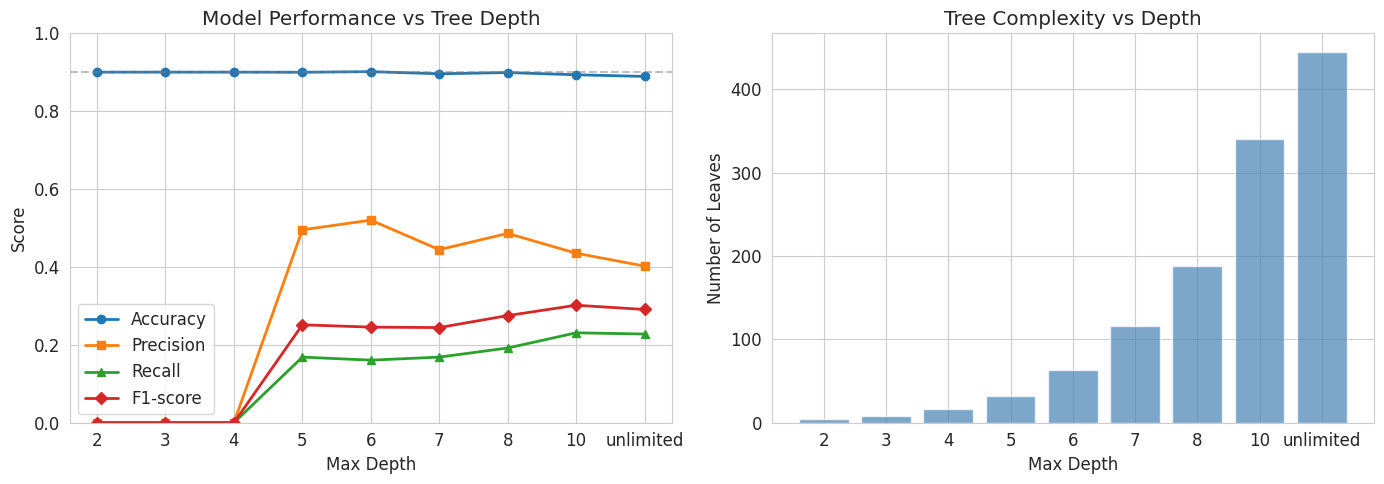


Key insight: After depth 5-6, the tree gets much more complex
but performance barely improves. We pick depth=5 as a good balance.


In [ ]:
# Visualize how depth affects performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot metrics vs depth
depth_labels = results_df['max_depth'].values
x_pos = range(len(depth_labels))

axes[0].plot(x_pos, results_df['accuracy'], 'o-', label='Accuracy', linewidth=2)
axes[0].plot(x_pos, results_df['precision'], 's-', label='Precision', linewidth=2)
axes[0].plot(x_pos, results_df['recall'], '^-', label='Recall', linewidth=2)
axes[0].plot(x_pos, results_df['f1'], 'D-', label='F1-score', linewidth=2)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(depth_labels)
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance vs Tree Depth')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% baseline')

# Plot number of leaves vs depth
axes[1].bar(x_pos, results_df['n_leaves'], color='steelblue', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(depth_labels)
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('Number of Leaves')
axes[1].set_title('Tree Complexity vs Depth')

plt.tight_layout()
plt.savefig('depth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey insight: After depth 5-6, the tree gets much more complex")
print("but performance barely improves. We pick depth=5 as a good balance.")

In [ ]:
# Train our final model with chosen parameters
# class_weight='balanced' tells the tree to pay MORE attention to the rare class
# (top 10% students). Without this, the tree might just predict "Not top 10%"
# for everyone and still get 90% accuracy.

final_tree = DecisionTreeClassifier(
    max_depth=5,             # Keep it interpretable
    min_samples_split=50,    # Need at least 50 students to split
    min_samples_leaf=25,     # Each leaf must have at least 25 students
    random_state=42,
    class_weight='balanced'  # Pay extra attention to the minority class
)

final_tree.fit(X_train, y_train)

print("Final Decision Tree trained!")
print(f"  Depth: {final_tree.get_depth()}")
print(f"  Number of leaves: {final_tree.get_n_leaves()}")
print(f"  Number of features used: {(final_tree.feature_importances_ > 0).sum()}")

Final Decision Tree trained!
  Depth: 5
  Number of leaves: 32
  Number of features used: 13


## Step 5: Evaluate the Model

### Why accuracy alone is misleading

Since only ~10% of students are in the top 10% (by definition!), a "dumb" model that always predicts "NOT top 10%" would be **90% accurate**. That sounds impressive but is completely useless.

That's why we also look at:
- **Precision**: Of all students the model *predicted* as top 10%, how many actually are? (avoids false alarms)
- **Recall**: Of all students who *actually are* top 10%, how many did the model find? (avoids missing them)
- **F1-score**: The balance between precision and recall (harmonic mean)
- **Confusion matrix**: Shows exactly where the model gets confused

In [ ]:
# Make predictions on the test set
y_pred = final_tree.predict(X_test)

# Calculate all metrics
print("=" * 60)
print("MODEL EVALUATION ON TEST SET")
print("=" * 60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")

print("\n" + "-" * 60)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Not Top 10%', 'Top 10%']))

# Compare with the "always predict 0" baseline
baseline_acc = (y_test == 0).mean()
print(f"\nBaseline (always predict 'Not Top 10%'): {baseline_acc:.3f} accuracy")
print(f"Our model accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Improvement over baseline: +{accuracy_score(y_test, y_pred) - baseline_acc:.3f}")

MODEL EVALUATION ON TEST SET

Accuracy:  0.702
Precision: 0.222
Recall:    0.794
F1-score:  0.347

------------------------------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

 Not Top 10%       0.97      0.69      0.81      5792
     Top 10%       0.22      0.79      0.35       641

    accuracy                           0.70      6433
   macro avg       0.60      0.74      0.58      6433
weighted avg       0.89      0.70      0.76      6433


Baseline (always predict 'Not Top 10%'): 0.900 accuracy
Our model accuracy: 0.702
Improvement over baseline: +-0.198


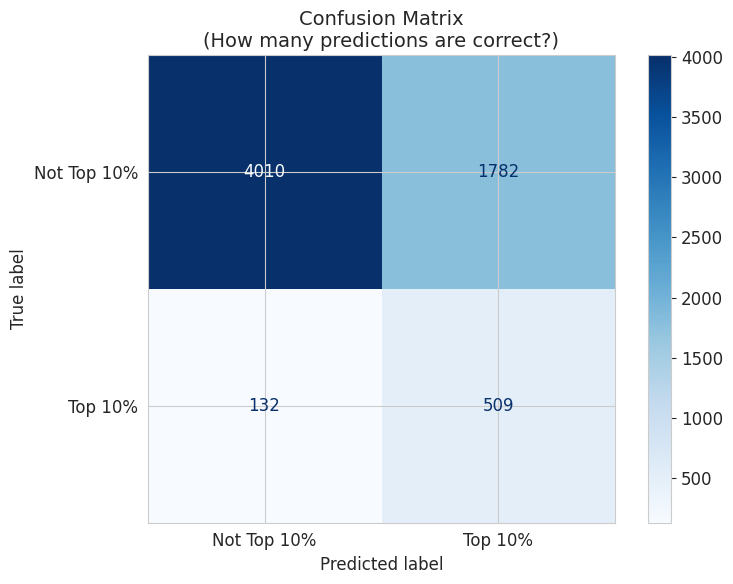


Reading the confusion matrix:
  True Negatives  (TN=4,010): Correctly identified as NOT top 10%
  False Positives (FP=1,782): Incorrectly predicted as top 10% (false alarm)
  False Negatives (FN=132): Missed actual top 10% students
  True Positives  (TP=509): Correctly identified as top 10%


In [ ]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Top 10%', 'Top 10%'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix\n(How many predictions are correct?)', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Explain the confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nReading the confusion matrix:")
print(f"  True Negatives  (TN={tn:,}): Correctly identified as NOT top 10%")
print(f"  False Positives (FP={fp:,}): Incorrectly predicted as top 10% (false alarm)")
print(f"  False Negatives (FN={fn:,}): Missed actual top 10% students")
print(f"  True Positives  (TP={tp:,}): Correctly identified as top 10%")

## Step 6: Visualize the Decision Tree

One of the best things about Decision Trees is that we can actually SEE the decisions the model makes. Each node in the tree represents a yes/no question about one feature.

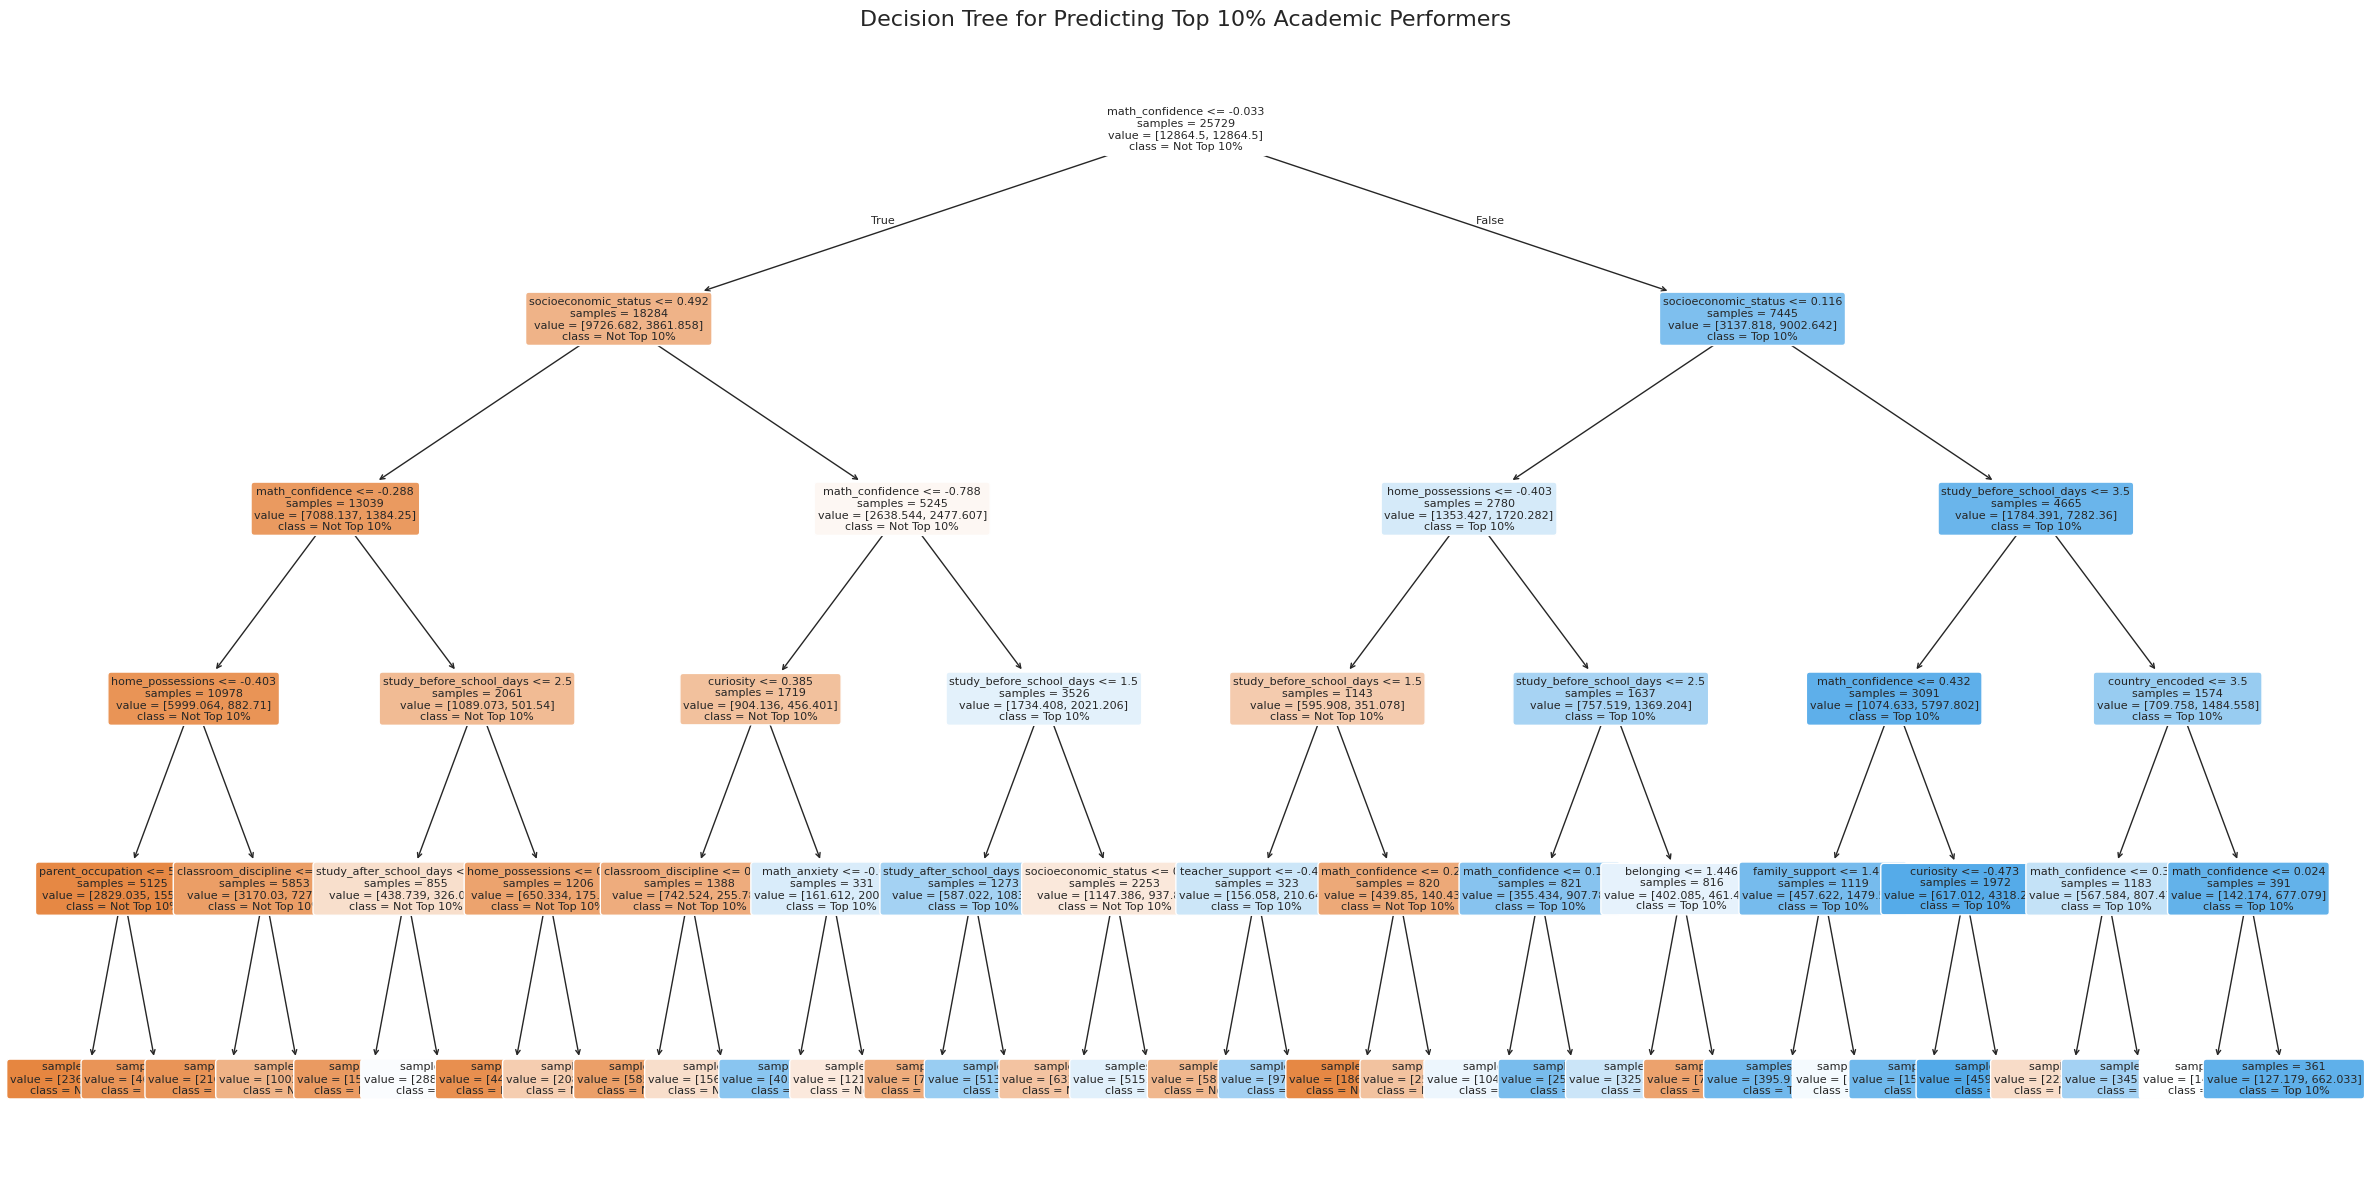

In [ ]:
# Visualize the full tree (depth=5)
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    final_tree,
    feature_names=list(features.columns),
    class_names=['Not Top 10%', 'Top 10%'],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=8,
    impurity=False
)
ax.set_title('Decision Tree for Predicting Top 10% Academic Performers', fontsize=16)
plt.tight_layout()
plt.savefig('decision_tree_full.png', dpi=150, bbox_inches='tight')
plt.show()

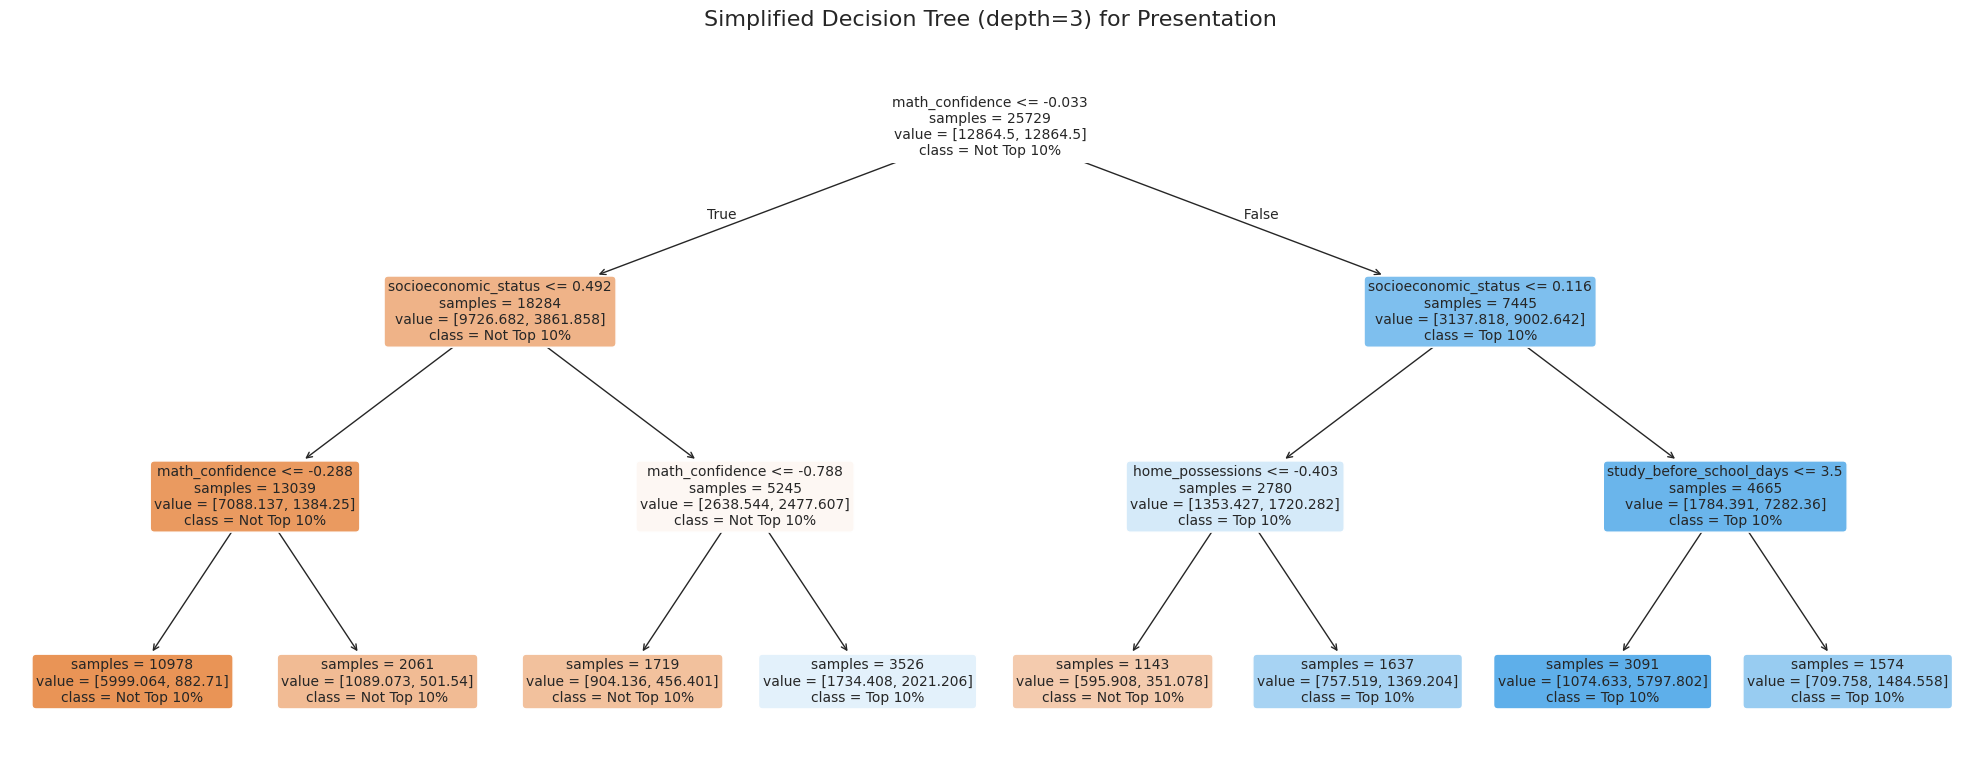

In [ ]:
# Let's also look at a simpler version (depth=3) for the presentation
simple_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42,
    class_weight='balanced'
)
simple_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    simple_tree,
    feature_names=list(features.columns),
    class_names=['Not Top 10%', 'Top 10%'],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=10,
    impurity=False
)
ax.set_title('Simplified Decision Tree (depth=3) for Presentation', fontsize=16)
plt.tight_layout()
plt.savefig('decision_tree_simple.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Print the tree rules as text (easier to read for explanation)
tree_rules = export_text(simple_tree, feature_names=list(features.columns), max_depth=3)
print("Decision Tree Rules (simplified, depth=3):")
print("=" * 60)
print(tree_rules)

Decision Tree Rules (simplified, depth=3):
|--- math_confidence <= -0.03
|   |--- socioeconomic_status <= 0.49
|   |   |--- math_confidence <= -0.29
|   |   |   |--- class: 0
|   |   |--- math_confidence >  -0.29
|   |   |   |--- class: 0
|   |--- socioeconomic_status >  0.49
|   |   |--- math_confidence <= -0.79
|   |   |   |--- class: 0
|   |   |--- math_confidence >  -0.79
|   |   |   |--- class: 1
|--- math_confidence >  -0.03
|   |--- socioeconomic_status <= 0.12
|   |   |--- home_possessions <= -0.40
|   |   |   |--- class: 0
|   |   |--- home_possessions >  -0.40
|   |   |   |--- class: 1
|   |--- socioeconomic_status >  0.12
|   |   |--- study_before_school_days <= 3.50
|   |   |   |--- class: 1
|   |   |--- study_before_school_days >  3.50
|   |   |   |--- class: 1



### Explaining Example Decisions

Let's trace through the tree for a few example students to show how it makes decisions.

In [ ]:
# Pick a few example students and trace their path through the tree
# Find one correctly predicted top-10% and one correctly predicted not-top-10%

# Get predictions and find examples
y_pred_simple = simple_tree.predict(X_test)
correct_top = X_test[(y_test == 1) & (y_pred_simple == 1)].head(1)
correct_not = X_test[(y_test == 0) & (y_pred_simple == 0)].head(1)

feature_names = list(features.columns)

def explain_prediction(tree, sample, feature_names, actual_label):
    """Trace a single prediction through the tree and explain it."""
    node_indicator = tree.decision_path(sample)
    node_ids = node_indicator.indices

    print(f"\n{'='*60}")
    pred = tree.predict(sample)[0]
    label_map = {0: 'Not Top 10%', 1: 'Top 10%'}
    print(f"Actual: {label_map[actual_label]} | Predicted: {label_map[pred]}")
    print(f"{'='*60}")
    print("\nThe tree asks these questions:")

    tree_structure = tree.tree_
    for i, node_id in enumerate(node_ids):
        if tree_structure.children_left[node_id] == -1:
            # Leaf node
            values = tree_structure.value[node_id][0]
            prediction = 'Top 10%' if values[1] > values[0] else 'Not Top 10%'
            print(f"  -> DECISION: {prediction}")
        else:
            feat_idx = tree_structure.feature[node_id]
            threshold = tree_structure.threshold[node_id]
            feat_name = feature_names[feat_idx]
            feat_value = sample.iloc[0, feat_idx]
            direction = "Yes (left)" if feat_value <= threshold else "No (right)"
            print(f"  Q{i+1}: Is {feat_name} <= {threshold:.2f}? "
                  f"(Student's value: {feat_value:.2f}) -> {direction}")

print("EXAMPLE 1: A correctly predicted TOP 10% student")
if len(correct_top) > 0:
    explain_prediction(simple_tree, correct_top, feature_names, 1)

print("\n\nEXAMPLE 2: A correctly predicted NOT top 10% student")
if len(correct_not) > 0:
    explain_prediction(simple_tree, correct_not, feature_names, 0)

EXAMPLE 1: A correctly predicted TOP 10% student

Actual: Top 10% | Predicted: Top 10%

The tree asks these questions:
  Q1: Is math_confidence <= -0.03? (Student's value: -0.18) -> Yes (left)
  Q2: Is socioeconomic_status <= 0.49? (Student's value: 0.85) -> No (right)
  Q3: Is math_confidence <= -0.79? (Student's value: -0.18) -> No (right)
  -> DECISION: Top 10%


EXAMPLE 2: A correctly predicted NOT top 10% student

Actual: Not Top 10% | Predicted: Not Top 10%

The tree asks these questions:
  Q1: Is math_confidence <= -0.03? (Student's value: -0.96) -> Yes (left)
  Q2: Is socioeconomic_status <= 0.49? (Student's value: 0.93) -> No (right)
  Q3: Is math_confidence <= -0.79? (Student's value: -0.96) -> Yes (left)
  -> DECISION: Not Top 10%


## Step 7: Feature Importance

The Decision Tree tells us which features it found most useful for splitting. Features with higher importance were more helpful in separating top-10% students from the rest.

**IMPORTANT CAUTION:** Feature importance tells us which variables are *useful for prediction*. It does NOT tell us that these features *cause* better academic performance. Correlation is not causation!

For example, if "home possessions" is important, it doesn't mean buying more things will make a student perform better. It might just be a proxy for other factors (like family income, which correlates with access to tutoring, stable home environment, etc.).

In [ ]:
# Feature importance from the final tree
importances = final_tree.feature_importances_
feature_imp = pd.DataFrame({
    'Feature': features.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Only show features that were actually used
feature_imp = feature_imp[feature_imp['Importance'] > 0]

print("Feature Importances (how much each feature helps the tree make decisions):")
print("=" * 60)
for _, row in feature_imp.iterrows():
    bar = '#' * int(row['Importance'] * 50)
    print(f"  {row['Feature']:15s} {row['Importance']:.3f} {bar}")

Feature Importances (how much each feature helps the tree make decisions):
  math_confidence 0.627 ###############################
  socioeconomic_status 0.205 ##########
  study_before_school_days 0.061 ###
  home_possessions 0.040 #
  study_after_school_days 0.014 
  classroom_discipline 0.013 
  curiosity       0.013 
  country_encoded 0.012 
  belonging       0.005 
  family_support  0.004 
  teacher_support 0.003 
  math_anxiety    0.002 
  parent_occupation 0.002 


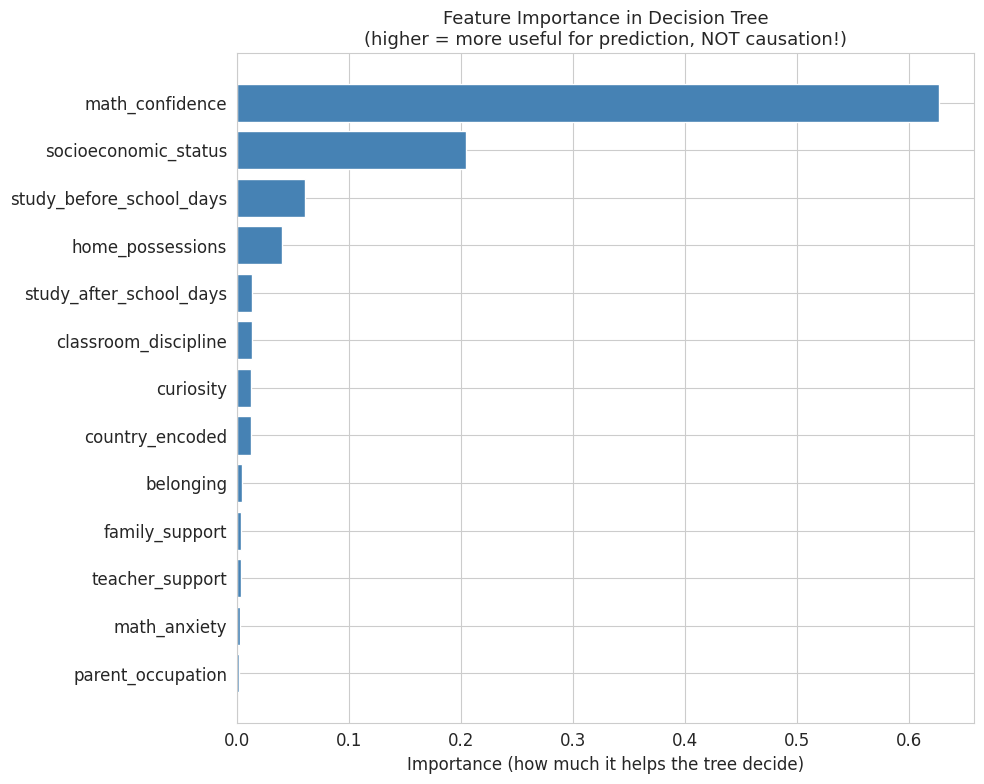

In [ ]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 8))
feature_imp_plot = feature_imp.sort_values('Importance', ascending=True)
ax.barh(feature_imp_plot['Feature'], feature_imp_plot['Importance'], color='steelblue')
ax.set_xlabel('Importance (how much it helps the tree decide)')
ax.set_title('Feature Importance in Decision Tree\n(higher = more useful for prediction, NOT causation!)',
             fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Performance Across Countries

Does the model work equally well for students in all five countries? Let's check.

In [ ]:
# Evaluate per country
test_countries = country_names.iloc[X_test.index]

country_full_names = {
    'ROU': 'Romania', 'DEU': 'Germany', 'FIN': 'Finland',
    'NLD': 'Netherlands', 'ESP': 'Spain'
}

print("Model Performance by Country:")
print("=" * 70)
print(f"{'Country':<15} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'N_test':>8}")
print("-" * 70)

country_results = []
for cnt_code in sorted(country_full_names.keys()):
    mask = test_countries == cnt_code
    if mask.sum() == 0:
        continue
    y_true_c = y_test[mask]
    y_pred_c = y_pred[mask]

    acc = accuracy_score(y_true_c, y_pred_c)
    prec = precision_score(y_true_c, y_pred_c, zero_division=0)
    rec = recall_score(y_true_c, y_pred_c, zero_division=0)
    f1 = f1_score(y_true_c, y_pred_c, zero_division=0)

    country_results.append({
        'Country': country_full_names[cnt_code],
        'Code': cnt_code,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'N': mask.sum()
    })
    print(f"{country_full_names[cnt_code]:<15} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f} {mask.sum():>8}")

country_results_df = pd.DataFrame(country_results)

Model Performance by Country:
Country           Accuracy  Precision     Recall         F1   N_test
----------------------------------------------------------------------
Germany              0.732      0.243      0.867      0.379     1199
Spain                0.644      0.200      0.790      0.319     1355
Finland              0.694      0.250      0.842      0.385     1387
Netherlands          0.650      0.187      0.778      0.301     1019
Romania              0.777      0.233      0.688      0.349     1473


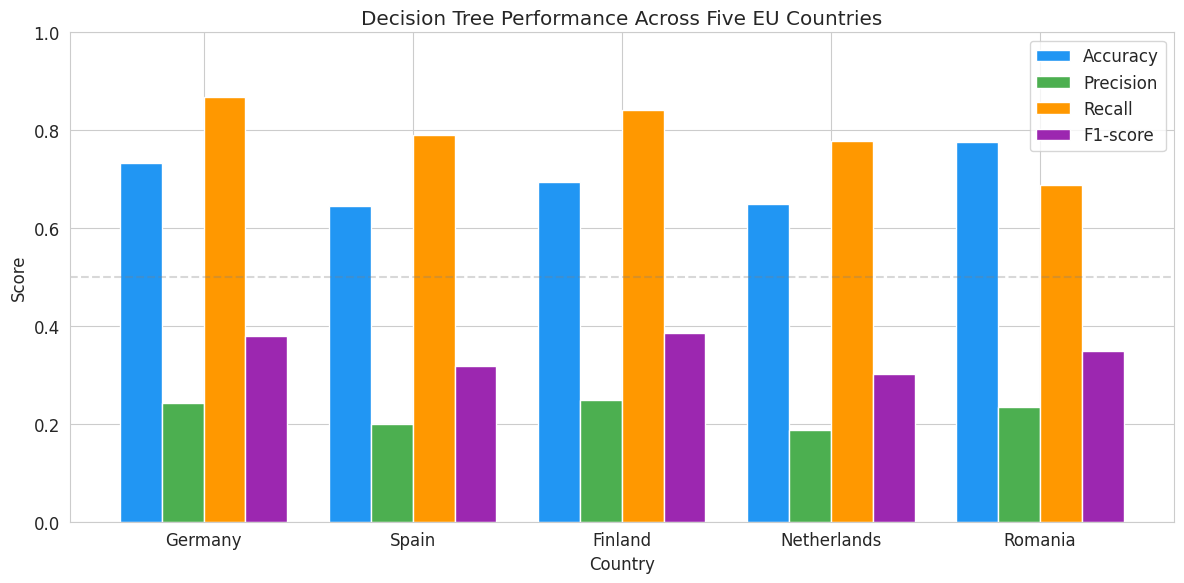

In [ ]:
# Visualize per-country performance
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(country_results_df))
width = 0.2

bars1 = ax.bar(x - 1.5*width, country_results_df['Accuracy'], width, label='Accuracy', color='#2196F3')
bars2 = ax.bar(x - 0.5*width, country_results_df['Precision'], width, label='Precision', color='#4CAF50')
bars3 = ax.bar(x + 0.5*width, country_results_df['Recall'], width, label='Recall', color='#FF9800')
bars4 = ax.bar(x + 1.5*width, country_results_df['F1'], width, label='F1-score', color='#9C27B0')

ax.set_xlabel('Country')
ax.set_ylabel('Score')
ax.set_title('Decision Tree Performance Across Five EU Countries')
ax.set_xticks(x)
ax.set_xticklabels(country_results_df['Country'])
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('performance_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 9: Additional Visualizations for Presentation

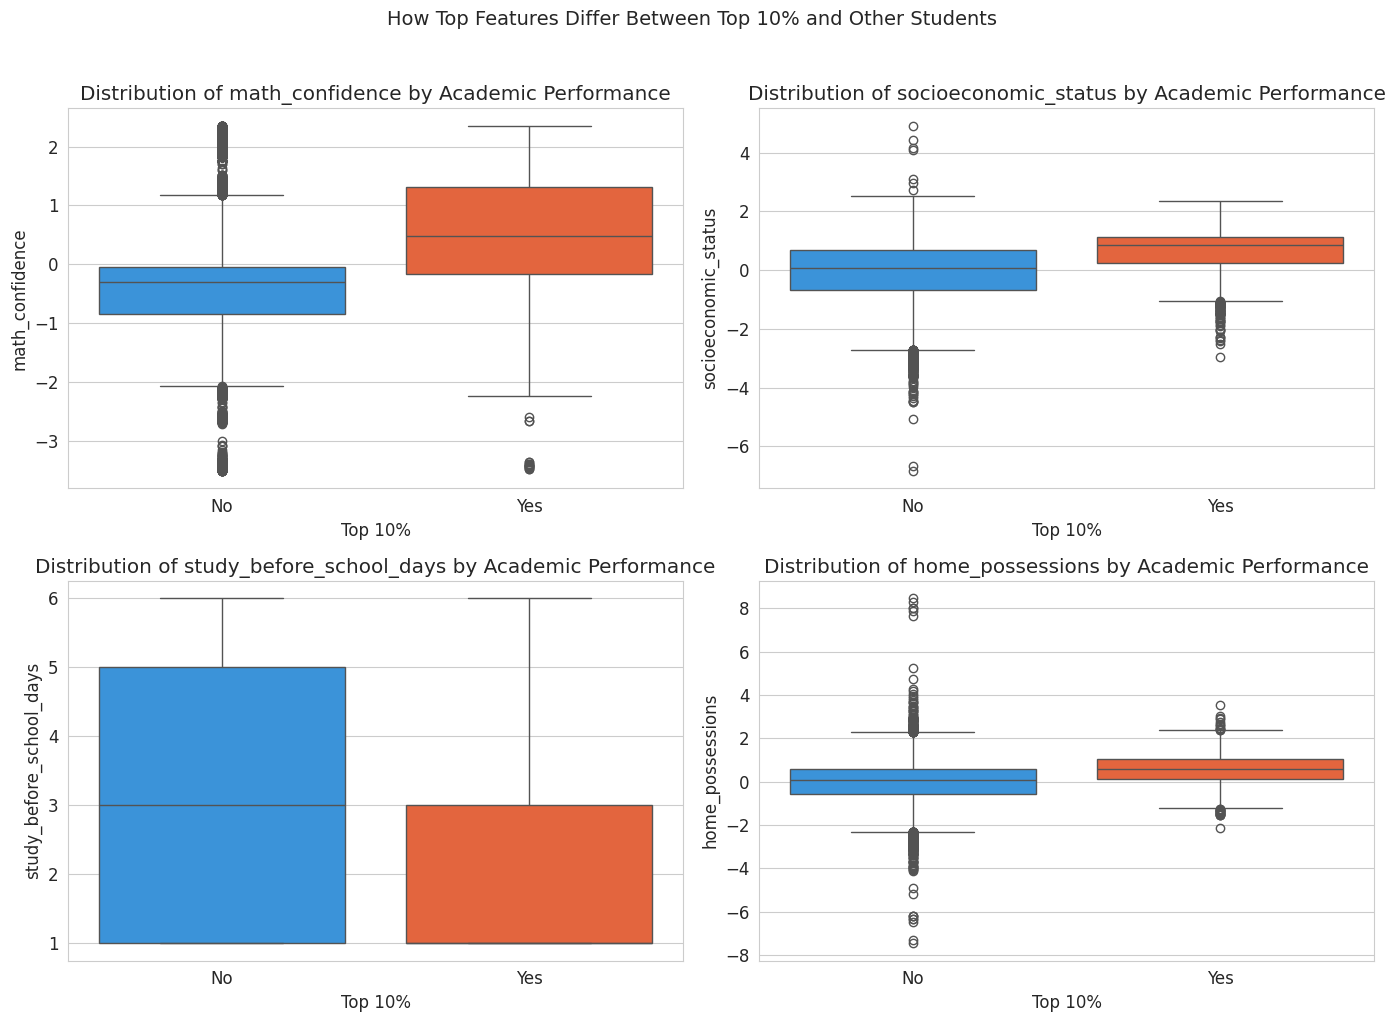

In [ ]:
# Plot 1: Distribution of key features by target class
top_features = feature_imp.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Reconstruct a dataframe with features and target for plotting
plot_df = features.copy()
plot_df['Top 10%'] = target.map({0: 'No', 1: 'Yes'})

for i, feat in enumerate(top_features):
    if feat in plot_df.columns:
        sns.boxplot(data=plot_df, x='Top 10%', y=feat, ax=axes[i],
                    palette=['#2196F3', '#FF5722'])
        axes[i].set_title(f'Distribution of {feat} by Academic Performance')

plt.suptitle('How Top Features Differ Between Top 10% and Other Students',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

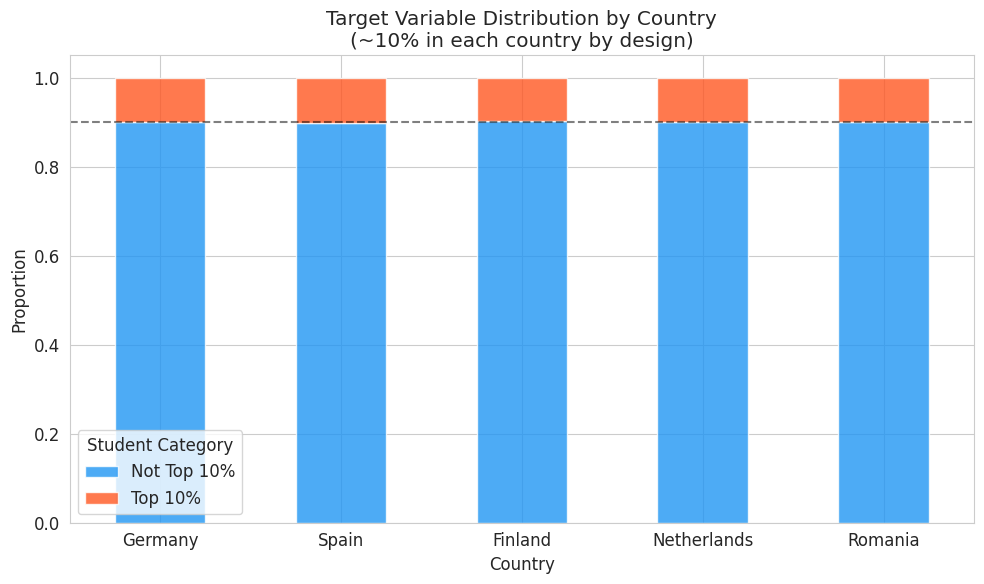

In [ ]:
# Plot 2: Target distribution by country (stacked bar)
# Useless - first cell does the distribution
fig, ax = plt.subplots(figsize=(10, 6))

country_target = df.groupby('country')['top_10_percent'].value_counts(normalize=True).unstack()
country_target.columns = ['Not Top 10%', 'Top 10%']
country_target.index = [country_full_names.get(c, c) for c in country_target.index]

country_target.plot(kind='bar', stacked=True, ax=ax,
                    color=['#2196F3', '#FF5722'], alpha=0.8)
ax.set_xlabel('Country')
ax.set_ylabel('Proportion')
ax.set_title('Target Variable Distribution by Country\n(~10% in each country by design)')
ax.legend(title='Student Category')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axhline(y=0.9, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

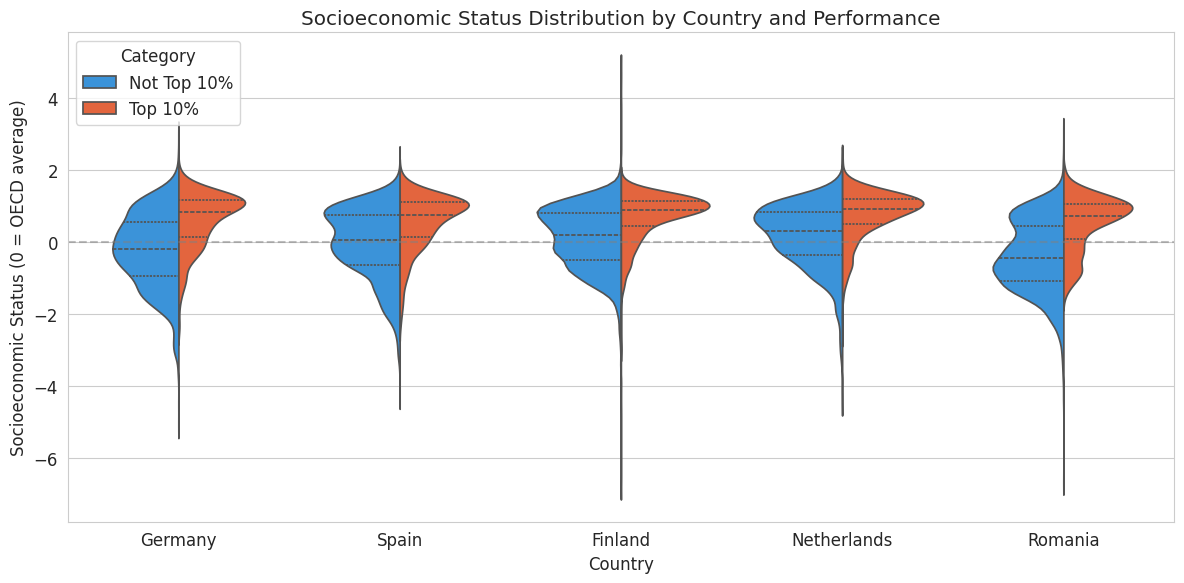

In [ ]:
# Plot 3: Socioeconomic status distribution by country and target
fig, ax = plt.subplots(figsize=(12, 6))

plot_df2 = df.copy()
plot_df2['Country'] = plot_df2['country'].map(country_full_names)
plot_df2['Category'] = plot_df2['top_10_percent'].map({0: 'Not Top 10%', 1: 'Top 10%'})

sns.violinplot(data=plot_df2, x='Country', y='socioeconomic_status', hue='Category',
               split=True, inner='quart', palette=['#2196F3', '#FF5722'], ax=ax)
ax.set_title('Socioeconomic Status Distribution by Country and Performance')
ax.set_ylabel('Socioeconomic Status (0 = OECD average)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('escs_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

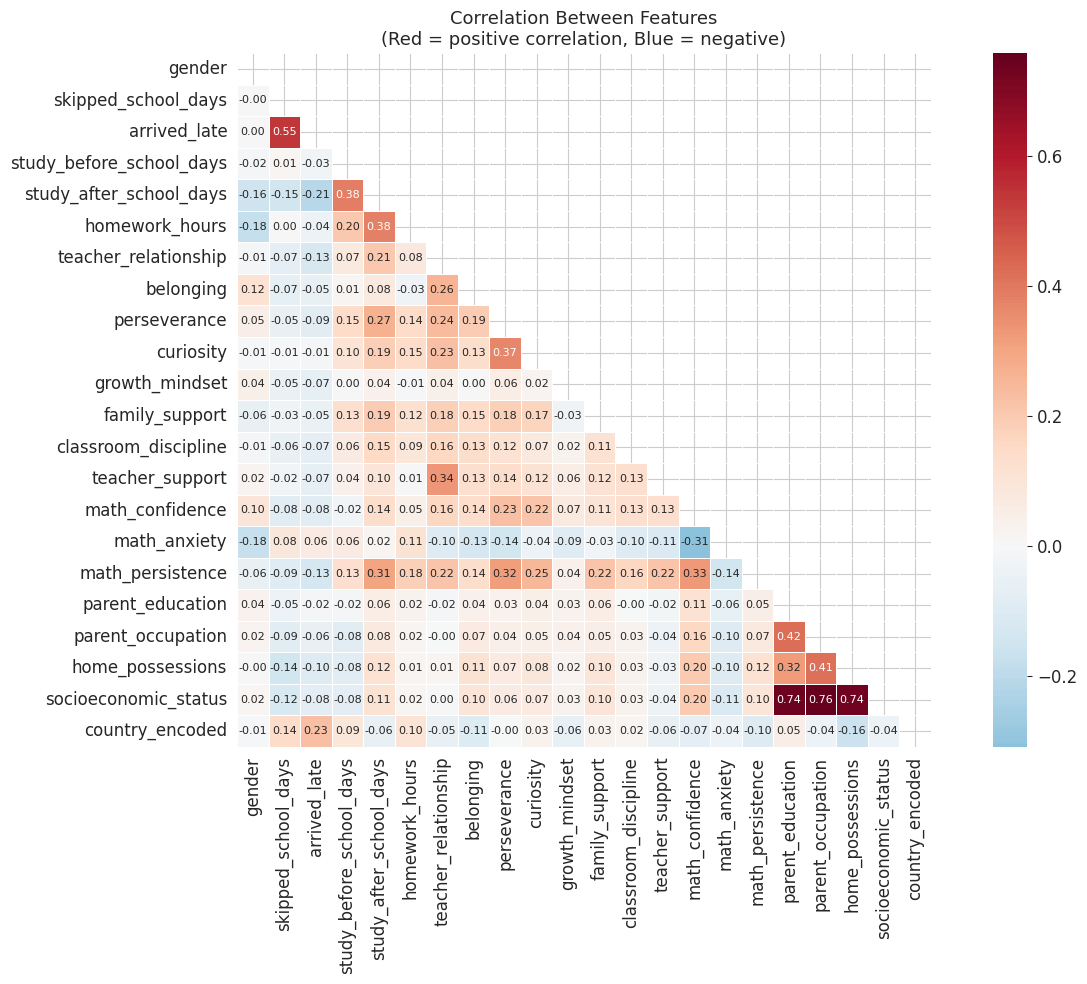

In [ ]:
# Plot 4: Correlation heatmap of features
fig, ax = plt.subplots(figsize=(14, 10))

# Select only numeric features for correlation
numeric_features = features.select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation Between Features\n(Red = positive correlation, Blue = negative)', fontsize=13)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:


# 1. Define correlation threshold (0.60 = eliminates pairs with > 60% correlation)
corr_threshold = 0.60

# Calculate absolute Spearman correlation matrix
corr_matrix_abs = df.select_dtypes(include=[np.number]).corr(method='spearman').abs()

# Identify features to drop (excluding the target column)
upper_tri = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > corr_threshold) and column != 'top_10_percent']

print("=" * 70)
print(f"1. CORRELATION REDUCTION (Threshold > {corr_threshold})")
print("=" * 70)
print(f"Features removed ({len(to_drop)}): {to_drop}")

# Create dataset with reduced correlation
df_uncorrelated = df.drop(columns=to_drop).copy()
print(f"Original feature count: {df.shape[1] - 1}")
print(f"Reduced feature count:  {df_uncorrelated.shape[1] - 1}\n")

# 2. Prepare features and target for retraining
X_uncorr = df_uncorrelated.drop(columns=['top_10_percent']).copy()
y_uncorr = df_uncorrelated['top_10_percent'].copy()

# Encode country column if present
country_col = 'country' if 'country' in X_uncorr.columns else 'CNT'
if country_col in X_uncorr.columns:
    X_uncorr['country_encoded'] = LabelEncoder().fit_transform(X_uncorr[country_col])
    X_uncorr = X_uncorr.drop(columns=[country_col])

# Fill missing values with median
for col in X_uncorr.select_dtypes(include=[np.number]).columns:
    X_uncorr[col] = X_uncorr[col].fillna(X_uncorr[col].median())

# 3. Split into Train/Test sets (80% / 20%)
X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(
    X_uncorr,
    y_uncorr,
    test_size=0.2,
    random_state=42,
    stratify=y_uncorr
)

# 4. Train Decision Tree on Uncorrelated Features
tree_uncorr = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42,
    class_weight='balanced'
)
tree_uncorr.fit(X_tr_u, y_tr_u)

# 5. Make Predictions and Calculate Metrics
y_pred_u = tree_uncorr.predict(X_te_u)

acc_u = accuracy_score(y_te_u, y_pred_u)
prec_u = precision_score(y_te_u, y_pred_u, zero_division=0)
rec_u = recall_score(y_te_u, y_pred_u, zero_division=0)
f1_u = f1_score(y_te_u, y_pred_u, zero_division=0)

print("=" * 70)
print("2. ACCURACY & EVALUATION ON CLEANED DATASET")
print("=" * 70)
print(f"Accuracy:  {acc_u:.3f}")
print(f"Precision: {prec_u:.3f}")
print(f"Recall:    {rec_u:.3f}")
print(f"F1-score:  {f1_u:.3f}\n")

# Compare with original model metrics if available in RAM
if 'y_test' in locals() and 'y_pred' in locals():
    acc_orig = accuracy_score(y_test, y_pred)
    prec_orig = precision_score(y_test, y_pred, zero_division=0)
    rec_orig = recall_score(y_test, y_pred, zero_division=0)
    f1_orig = f1_score(y_test, y_pred, zero_division=0)

    comparison_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
        'Original Model': [acc_orig, prec_orig, rec_orig, f1_orig],
        'Uncorrelated Model': [acc_u, prec_u, rec_u, f1_u],
        'Difference': [acc_u - acc_orig, prec_u - prec_orig, rec_u - rec_orig, f1_u - f1_orig]
    })

    print("COMPARISON: Original Model vs Uncorrelated Model:")
    display(comparison_df.round(3))

1. CORRELATION REDUCTION (Threshold > 0.6)
Features removed (1): ['socioeconomic_status']
Original feature count: 22
Reduced feature count:  21

2. ACCURACY & EVALUATION ON CLEANED DATASET
Accuracy:  0.737
Precision: 0.238
Recall:    0.744
F1-score:  0.361

COMPARISON: Original Model vs Uncorrelated Model:


,Metric,Original Model,Uncorrelated Model,Difference
0,Accuracy,0.702,0.737,0.035
1,Precision,0.222,0.238,0.016
2,Recall,0.794,0.744,-0.050
3,F1-score,0.347,0.361,0.014


## Step 10: Summary and Interpretation

### What did we find?

Our Decision Tree can predict top academic performers with reasonable accuracy using only background information. The most important features tend to be related to:

1. **Math confidence** (math_confidence) - students who believe they can do well in math tend to actually perform better
2. **Socioeconomic status** (socioeconomic_status, home_possessions) - students from wealthier families tend to have more resources
3. **Study habits** (study_before_school_days, study_after_school_days) - time spent studying matters
4. **Parental education** (parent_education) - parents' educational level correlates with children's performance
5. **Classroom environment** (classroom_discipline) - orderly classrooms correlate with better outcomes

### Important: Correlation vs Causation

Our model finds **patterns and associations**, not causes. For example:
- Having more possessions at home correlates with better performance, but buying more things won't automatically improve grades. Possessions are a proxy for family wealth, which correlates with access to tutoring, stable environments, etc.
- High parental education correlates with student success, but this could work through genetics, home environment, financial resources, or cultural emphasis on education.
- Low math anxiety correlates with top performance, but we cannot say whether reducing anxiety causes better performance, or whether being naturally good at math reduces anxiety.

The tree shows us **what predicts performance**, not **what causes it**.

## Limitations of This Study

1. **We only use one plausible value (PV1)**: PISA provides 10 plausible values per subject to account for measurement uncertainty. A full analysis would repeat the analysis with each and average the results. We use only PV1 for simplicity.

2. **Missing data handling is very basic**: We fill missing values with the median, which can introduce bias. More sophisticated methods (like multiple imputation) exist but are beyond our scope.

3. **Decision Tree limitations**: A single Decision Tree is not the most powerful model. Ensemble methods (Random Forest, Gradient Boosting) would likely perform better, but we chose interpretability over raw performance.

4. **Country comparisons may be unfair**: Education systems differ enormously between countries. What makes a student "top 10%" in Romania might be different from what makes one "top 10%" in Finland.

5. **Socioeconomic bias**: The model may learn to predict wealth rather than true academic potential. A student from a disadvantaged background might be brilliant but score lower on PISA due to lack of resources.

6. **Cross-sectional data**: PISA is a snapshot in time (one test day in 2022). It cannot capture growth, effort over time, or recent changes in a student's life.

### Why This Model Should NOT Be Used for University Admissions

- It would systematically disadvantage students from lower socioeconomic backgrounds
- It treats "country" as a feature, which could lead to national discrimination
- It cannot measure motivation, creativity, or unique talents
- The accuracy is not high enough for individual decisions (many false positives and negatives)
- Using such a model would violate principles of equal opportunity and fairness

### Possible Next Steps

1. Try ensemble methods (Random Forest) to see if performance improves
2. Use all 10 plausible values and average the results
3. Add more countries or compare EU vs non-EU
4. Investigate fairness: does the model work equally well for all socioeconomic groups?
5. Use SHAP values for more detailed feature importance analysis
6. Build separate models per country and compare which features matter where

In [ ]:
# Final summary table
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"\nDataset: OECD PISA 2022")
print(f"Countries: Romania, Germany, Finland, Netherlands, Spain")
print(f"Total students: {len(df):,}")
print(f"Features used: {features.shape[1]}")
print(f"Model: Decision Tree (max_depth=5)")
print(f"\nTest Set Results:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"  F1-score:  {f1_score(y_test, y_pred):.3f}")
print(f"\nTop 3 most important features:")
for i, (_, row) in enumerate(feature_imp.head(3).iterrows()):
    print(f"  {i+1}. {row['Feature']} (importance: {row['Importance']:.3f})")
print(f"\nConclusion: Background information CAN partially predict")
print(f"top academic performance, but with significant limitations.")
print(f"The model should be used for research insights only.")


PROJECT SUMMARY

Dataset: OECD PISA 2022
Countries: Romania, Germany, Finland, Netherlands, Spain
Total students: 32,162
Features used: 22
Model: Decision Tree (max_depth=5)

Test Set Results:
  Accuracy:  0.702
  Precision: 0.222
  Recall:    0.794
  F1-score:  0.347

Top 3 most important features:
  1. math_confidence (importance: 0.627)
  2. socioeconomic_status (importance: 0.205)
  3. study_before_school_days (importance: 0.061)

Conclusion: Background information CAN partially predict
top academic performance, but with significant limitations.
The model should be used for research insights only.
